|                |   |
:----------------|---|
| **Nombre**     |Jocelyn Jiménez Buenrostro  |
| **Fecha**      |23 de marzo 2026   |
| **Expediente** |738498   |



In [1]:
import pandas as pd

In [2]:
from google.colab import files
uploaded = files.upload()

Saving brain_tumor_dataset.csv to brain_tumor_dataset.csv


In [3]:
df = pd.read_csv("brain_tumor_dataset.csv")
df.head()

,Patient_ID,Age,Gender,Tumor_Type,Tumor_Size,Location,Histology,Stage,Symptom_1,Symptom_2,Symptom_3,Radiation_Treatment,Surgery_Performed,Chemotherapy,Survival_Rate,Tumor_Growth_Rate,Family_History,MRI_Result,Follow_Up_Required
0,1,73,Male,Malignant,5.375612,Temporal,Astrocytoma,III,Vision Issues,Seizures,Seizures,No,No,No,51.312579,0.111876,No,Positive,Yes
1,2,26,Male,Benign,4.847098,Parietal,Glioblastoma,II,Headache,Headache,Nausea,Yes,Yes,Yes,46.373273,2.165736,Yes,Positive,Yes
2,3,31,Male,Benign,5.588391,Parietal,Meningioma,I,Vision Issues,Headache,Seizures,No,No,No,47.072221,1.884228,No,Negative,No
3,4,29,Male,Malignant,1.436600,Temporal,Medulloblastoma,IV,Vision Issues,Seizures,Headache,Yes,No,Yes,51.853634,1.283342,Yes,Negative,No
4,5,54,Female,Benign,2.417506,Parietal,Glioblastoma,I,Headache,Headache,Seizures,No,No,Yes,54.708987,2.069477,No,Positive,Yes


Numéricas: Age, Tumor_Size, Survival_Rate, Tumor_Growth_Rate
* Int: Age
* Float: Tumor_Size, Survival_Rate, Tumor_Growth_Rate

Categóricas: Gender, Tumor_Type, Location, Histology, Stage, Symptom_1, Symptom_2, Symptom_3, Radiation_Treatment, Surgery_Performed, Chemotherapy, Family_History, Follow_Up_Required, MRI_Result

* Categóticas ordinales: Stage

Booleanas: Radiation_Treatment, Surgery_Performed, Chemotherapy, Family_History, Follow_Up_Required, Gender

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Patient_ID           20000 non-null  int64  
 1   Age                  20000 non-null  int64  
 2   Gender               20000 non-null  object 
 3   Tumor_Type           20000 non-null  object 
 4   Tumor_Size           20000 non-null  float64
 5   Location             20000 non-null  object 
 6   Histology            20000 non-null  object 
 7   Stage                20000 non-null  object 
 8   Symptom_1            20000 non-null  object 
 9   Symptom_2            20000 non-null  object 
 10  Symptom_3            20000 non-null  object 
 11  Radiation_Treatment  20000 non-null  object 
 12  Surgery_Performed    20000 non-null  object 
 13  Chemotherapy         20000 non-null  object 
 14  Survival_Rate        20000 non-null  float64
 15  Tumor_Growth_Rate    20000 non-null 

In [5]:
df.describe()

,Patient_ID,Age,Tumor_Size,Survival_Rate,Tumor_Growth_Rate
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,10000.500000,49.433700,5.236552,70.131699,1.547701
std,5773.647028,17.389296,2.754359,17.270834,0.835995
min,1.000000,20.000000,0.500410,40.002386,0.100017
25%,5000.750000,34.000000,2.836686,55.224439,0.830433
50%,10000.500000,49.000000,5.200675,70.305066,1.541821
75%,15000.250000,65.000000,7.624299,85.043395,2.262484
max,20000.000000,79.000000,9.999420,99.998125,2.999835


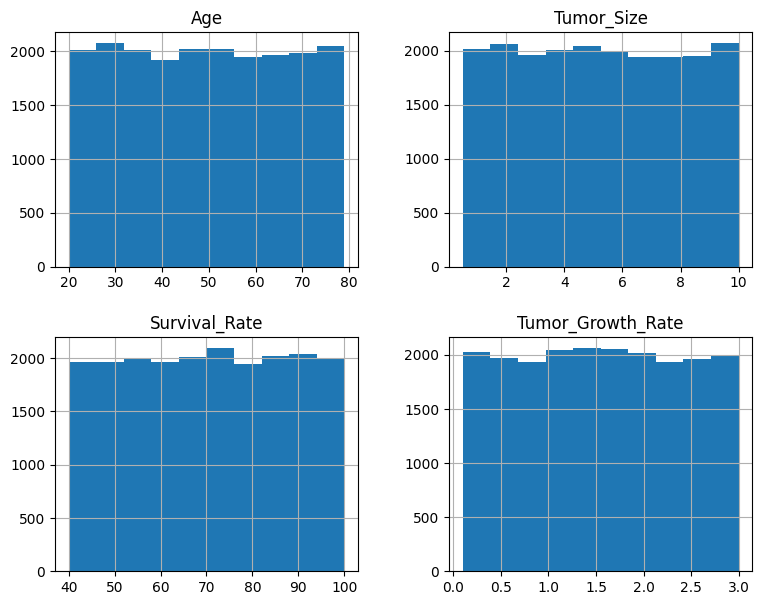

In [15]:
import matplotlib.pyplot as plt

df.hist(figsize=(9,7))
plt.show()

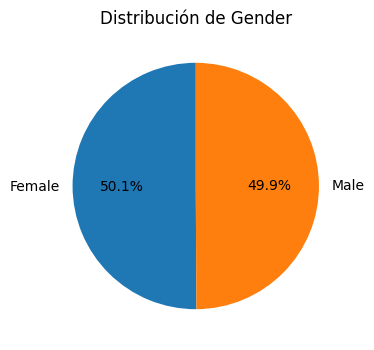

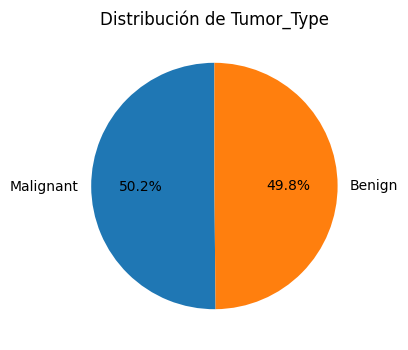

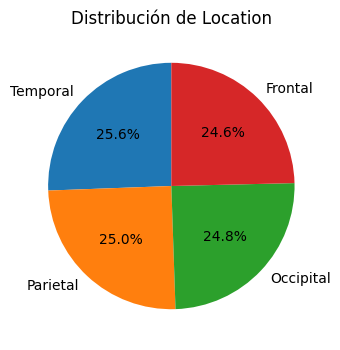

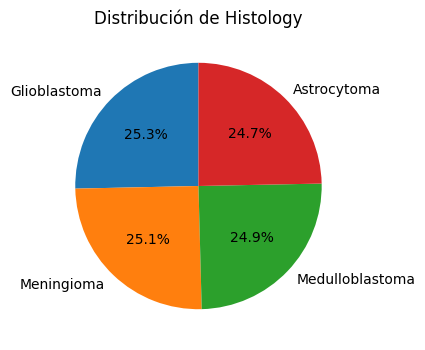

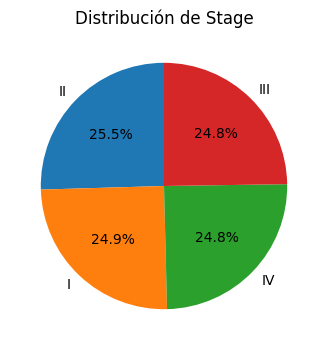

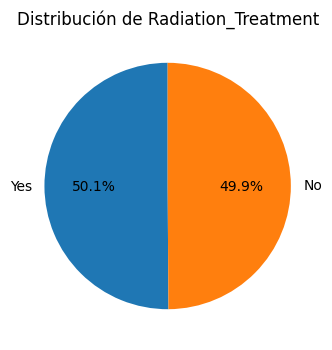

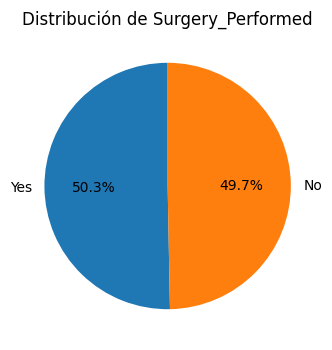

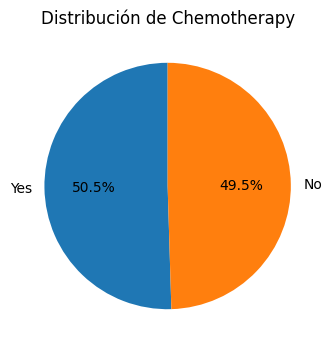

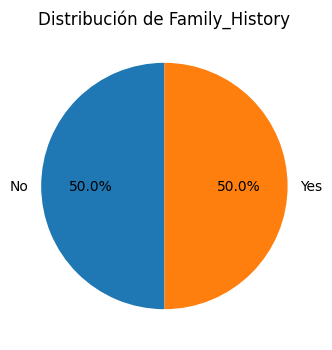

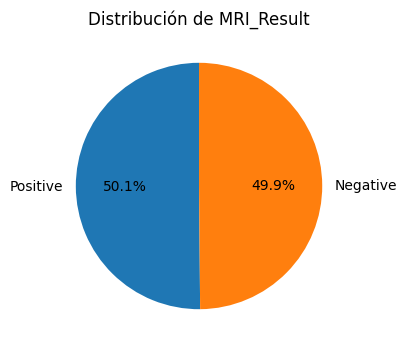

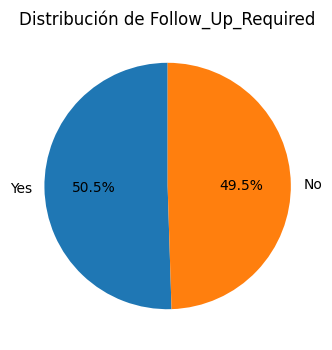

In [16]:
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    plt.figure(figsize=(4,4))

    df[col].value_counts().plot(
        kind="pie",
        autopct="%1.1f%%",
        startangle=90
    )

    plt.title(f"Distribución de {col}")
    plt.ylabel("")
    plt.show()

¿Cuántas personas recibieron tratamiento de radiación, cirugía y quimioterapia?


In [17]:
((df["Radiation_Treatment"] == "Yes") & (df["Surgery_Performed"] == "Yes") & (df["Chemotherapy"] == "Yes")).sum()

np.int64(2590)

---

In [9]:
df = df.drop(columns=["Symptom_1", "Symptom_2", "Symptom_3", "Patient_ID"])

In [18]:
y = df["Tumor_Type"].map({"Benign":0, "Malignant":1})
X = df.drop("Tumor_Type", axis=1)

In [19]:
num = ["Age", "Tumor_Size", "Survival_Rate", "Tumor_Growth_Rate"]
ordi = ["Stage"]
cat = ["Gender", "Location", "Histology"]
bools = ["Surgery_Performed", "Radiation_Treatment", "Chemotherapy","Family_History","Follow_Up_Required"]

In [20]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num),
        ("ord", OrdinalEncoder(categories=[["I", "II", "III", "IV"]]), ordi),
        ("cat", OneHotEncoder(drop="first"), cat),
        ("bool", OneHotEncoder(drop="if_binary"), bools)
    ]
)

In [21]:
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

model = Pipeline([
    ("prep", preprocessor),
    ("svc", SVC(kernel="linear", probability=True))
])

In [23]:
from sklearn.model_selection import cross_val_score
f1_scores = cross_val_score(model, X, y, cv=10, scoring="f1")

print("F1 promedio:", f1_scores.mean())

F1 promedio: 0.4873014954476573


In [26]:
model.fit(X,y)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'Tumor_Size',
                                                   'Survival_Rate',
                                                   'Tumor_Growth_Rate']),
                                                 ('ord',
                                                  OrdinalEncoder(categories=[['I',
                                                                              'II',
                                                                              'III',
                                                                              'IV']]),
                                                  ['Stage']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['Gender', 'Location',
                                                   'Histology']),
                                                 ('bool',
                                                  OneHotEncoder(drop='if_binary'),
                                                  ['Surgery_Performed',
                                                   'Radiation_Treatment',
                                                   'Chemotherapy',
                                                   'Family_History',
                                                   'Follow_Up_Required'])])),
                ('svc', SVC(kernel='linear', probability=True))])

In [27]:
model.score(X,y)

0.50695

In [45]:
from skopt.space import Real
search_space = {
    'svc__C': Real(1e-3, 1e3, prior='log-uniform')}

In [46]:
from skopt import BayesSearchCV

opt_baye = BayesSearchCV(
    model,
    search_space,
    n_iter=10,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    random_state=42
)

In [ ]:
opt_baye.fit(X,y)

In [ ]:
print("Mejores parámetros:", opt_baye.best_params_)
print("Mejor score:", opt_baye.best_score_)

Score F1 es: (2*(recall)*(precission))/((recall)+(precission))

recall= TP/(TP+FN)
Precission = TP/(TP+FP)

Esto se usa con el objetivo de reducir los **falsos** positivos sin decir que todos son negativos. Le da más peso a los "1" dejando a un lado los "0".

AUC: área bajo la curva (Receiver Operating Characteristic)


Propósito de cross validation, revisar que generalice bien